# SMILES Normalisation Verification

Systematically check the correctness of SMILES normalisation applied by `normalise_smiles.py`.

The script performs two kinds of normalisation:
- **Annotation filtering** — Remove disconnected text-annotation fragments (Roman numerals, stray parentheses, punctuation, etc.)
- **R-group normalisation** — Convert wildcards: `[N*]→[RN]`, bare `*→[label]`

**Verification strategy:**
1. **Summary statistics** — Overview of how many SMILES changed and what patterns were affected
2. **Annotation filtering checks** — Verify fragment removal is correct and conservative
3. **R-group pattern-level checks** — Verify each normalisation rule (`[N*]→[RN]`, bare `*→[label]`)
4. **MOL-file cross-validation** — Compare assigned labels against MOL-file element symbols
5. **Visual inspection** — Display original images alongside before/after SMILES for spot-checking
6. **Edge-case audit** — Flag suspicious or potentially incorrect normalisations

In [1]:
import os
import re
import sys
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML

try:
    from rdkit import Chem, RDLogger
    from rdkit.Chem import Draw
    RDLogger.DisableLog('rdApp.*')
    HAS_RDKIT = True
except ImportError:
    HAS_RDKIT = False
    print('WARNING: RDKit not available, some checks will be skipped.')

# Project root
PROJECT_ROOT = Path('../').resolve()
DATA_DIR = PROJECT_ROOT / 'data'

# Add scripts to path for importing normalise_smiles
sys.path.insert(0, str(Path('.').resolve()))
from scripts.normalise_smiles import (
    normalise_rgroup,
    remove_annotation_fragments,
    _is_annotation_fragment,
    parse_mol_element_symbols,
    _count_bare_stars,
    _get_ordered_bare_labels,
    _is_valid_label,
    _clean_element_symbol,
)

print(f'Project root: {PROJECT_ROOT}')
print(f'RDKit available: {HAS_RDKIT}')

Project root: /home/zqlyu2/projects/Markush
RDKit available: True


## 1. Load Data

In [2]:
CSV_ORIG = DATA_DIR / 'uspto_mol' / 'train_680k.csv'
CSV_NORM = DATA_DIR / 'uspto_mol' / 'train_680k_normalised.csv'

print(f'Loading original:    {CSV_ORIG}')
df_orig = pd.read_csv(CSV_ORIG)
print(f'  → {len(df_orig)} rows, columns: {list(df_orig.columns)}')

print(f'Loading normalised:  {CSV_NORM}')
df_norm = pd.read_csv(CSV_NORM)
print(f'  → {len(df_norm)} rows')

assert len(df_orig) == len(df_norm), 'Row count mismatch!'

Loading original:    /home/zqlyu2/projects/Markush/data/uspto_mol/train_680k.csv
  → 680220 rows, columns: ['file_path', 'mol_path', 'raw_SMILES', 'SMILES', 'node_coords', 'edges']
Loading normalised:  /home/zqlyu2/projects/Markush/data/uspto_mol/train_680k_normalised.csv
  → 680220 rows


In [3]:
# Build a combined view
df = pd.DataFrame({
    'file_path': df_orig['file_path'],
    'mol_path': df_orig['mol_path'],
    'raw_SMILES': df_orig.get('raw_SMILES', df_orig['SMILES']),
    'smiles_before': df_orig['SMILES'],
    'smiles_after': df_norm['SMILES'],
})
df['changed'] = df['smiles_before'] != df['smiles_after']
df_changed = df[df['changed']].copy()

print(f'Total rows:   {len(df)}')
print(f'Changed rows: {len(df_changed)} ({100*len(df_changed)/len(df):.1f}%)')
print(f'Unchanged:    {len(df) - len(df_changed)}')

Total rows:   680220
Changed rows: 265627 (39.1%)
Unchanged:    414593


## 2. Summary Statistics

In [4]:
# Classify what kind of wildcards were present BEFORE normalisation
def classify_wildcards(smiles):
    """Return set of wildcard types found in a SMILES string."""
    if not isinstance(smiles, str):
        return set()
    types = set()
    # [N*] numbered wildcard
    if re.search(r'\[\d+\*\]', smiles):
        types.add('numbered [N*]')
    # bare * outside brackets
    if _count_bare_stars(smiles) > 0:
        types.add('bare *')
    # Already-labelled [RN]
    if re.search(r'\[R\d+\]', smiles):
        types.add('[RN] already')
    # Other bracket wildcards like [X], [A], etc.
    if re.search(r'\[[A-Z][a-z0-9]*\*\]', smiles):
        types.add('other bracket')
    return types

df_changed['wildcard_types'] = df_changed['smiles_before'].apply(classify_wildcards)

# Count each type
type_counts = Counter()
for types in df_changed['wildcard_types']:
    for t in types:
        type_counts[t] += 1

print('Wildcard types in changed rows:')
for t, c in type_counts.most_common():
    print(f'  {t:25s} {c:>6d}')

Wildcard types in changed rows:
  numbered [N*]             155711
  bare *                    109828
  [RN] already               12769
  other bracket                705


In [5]:
# What labels appear in the normalised SMILES?
label_counter = Counter()
for smi in df_norm['SMILES']:
    if isinstance(smi, str):
        for m in re.finditer(r'\[([A-Z][A-Za-z0-9]*)\]', smi):
            label = m.group(1)
            # Filter to R-group-like labels (not element symbols)
            if label.startswith('R') or label in ('X', 'A', 'M', 'Q', 'L', 'Ar', 'Hal'):
                label_counter[label] += 1

print(f'Top 30 R-group labels in normalised SMILES:')
for label, count in label_counter.most_common(30):
    print(f'  [{label}]  {count:>6d}')

Top 30 R-group labels in normalised SMILES:
  [R1]  149237
  [R2]  131368
  [R]  126293
  [R3]  105416
  [X]   87269
  [R4]   81044
  [R5]   61463
  [R6]   45963
  [R7]   33448
  [A]   30755
  [Ar]   26605
  [R8]   25988
  [R9]   20500
  [R10]   17227
  [Q]   15589
  [R11]   14474
  [M]   14463
  [R12]   11722
  [L]   11472
  [R13]    9808
  [Rb]    8945
  [R14]    8332
  [RaH]    7017
  [R15]    6717
  [R16]    6407
  [R17]    4404
  [R21]    3926
  [R18]    3661
  [R20]    3569
  [R22]    3274


## 3. Annotation Fragment Filtering

Verify that `remove_annotation_fragments` correctly identifies and removes text annotations
(Roman numerals, stray parentheses, punctuation, etc.) while preserving real chemistry.

In [6]:
# 3a. Overall filtering impact
before_smiles = df['smiles_before']
after_filter = before_smiles.apply(remove_annotation_fragments)
filter_changed = before_smiles != after_filter
n_filter_changed = filter_changed.sum()

print(f'Rows affected by annotation filtering: {n_filter_changed:,} / {len(df):,} '
      f'({100 * n_filter_changed / len(df):.1f}%)')

# Count how many fragments removed per affected row
def count_removed(before, after):
    if before == after:
        return 0
    return len(before.split('.')) - len(after.split('.'))

frag_removed_counts = pd.Series(
    [count_removed(b, a) for b, a in zip(before_smiles, after_filter)],
    index=df.index,
)
print(f'\nFragments removed per affected row:')
print(frag_removed_counts[frag_removed_counts > 0].describe())

Rows affected by annotation filtering: 89,442 / 680,220 (13.1%)

Fragments removed per affected row:
count    89442.000000
mean         2.313980
std          2.708134
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max        136.000000
dtype: float64


In [7]:
# 3b. Catalogue which fragments are being removed and their frequencies
removed_frags = Counter()
for b, a in zip(before_smiles[filter_changed], after_filter[filter_changed]):
    b_frags = b.split('.')
    a_frags = a.split('.')
    # Simple difference: fragments in before but not in after
    a_set = Counter(a_frags)
    for f in b_frags:
        if a_set[f] > 0:
            a_set[f] -= 1
        else:
            removed_frags[f] += 1

print(f'Unique fragment types removed: {len(removed_frags)}')
print(f'\nTop 30 most frequently removed fragments:')
for frag, cnt in removed_frags.most_common(30):
    print(f'  {frag:30s}  ×{cnt:>6d}  annotation={_is_annotation_fragment(frag)}')

Unique fragment types removed: 20515

Top 30 most frequently removed fragments:
  [(]                             × 25764  annotation=True
  [)]                             × 24132  annotation=True
  [HH]                            × 22214  annotation=True
  [,]                             ×  9245  annotation=True
  [+]                             ×  9005  annotation=True
  [[]                             ×  6615  annotation=True
  [V]I                            ×  6599  annotation=True
  II                              ×  6403  annotation=True
  []]                             ×  6126  annotation=True
  ]                               ×  4834  annotation=True
  [or]                            ×  4553  annotation=True
  [0]                             ×  3847  annotation=True
  [2HH]                           ×  3652  annotation=True
  I[IH]I                          ×  3007  annotation=True
  [                               ×  2846  annotation=True
  [;]                             ×

In [8]:
# 3c. Categorise removed fragments by annotation type
categories = {
    'bracket_punct': [],     # [(], [)], [,], [;], etc.
    'roman_numeral': [],     # II, I[V]I, I[V](I)I, etc.
    'paren_label': [],       # [(IX)], [(A)], [(1)], etc.
    'bare_digit': [],        # [0], [1], [2]
    'known_text': [],        # [or], [and], [HH], [+], [-]
    'broken_bracket': [],    # [, [1, [2, ]
    'other': [],
}

_KNOWN_TEXT = frozenset(['[or]', '[and]', '[HH]', '[2HH]', '[3HH]', '[+]', '[-]'])
_BRACKET_PUNCT = frozenset(['[(]', '[)]', '[[]', '[]]'])

for frag, cnt in removed_frags.items():
    if frag in _BRACKET_PUNCT:
        categories['bracket_punct'].append((frag, cnt))
    elif frag in _KNOWN_TEXT:
        categories['known_text'].append((frag, cnt))
    elif frag in (']', '[') or re.fullmatch(r'\[\d*', frag):
        categories['broken_bracket'].append((frag, cnt))
    elif re.fullmatch(r'\[\(.*\).*\]', frag):
        categories['paren_label'].append((frag, cnt))
    elif re.fullmatch(r'\[\d+\]', frag):
        categories['bare_digit'].append((frag, cnt))
    elif re.fullmatch(r'[IVX\[\]()H\d+\-]+', frag):
        letters = re.sub(r'[\[\]()H\d+\-]', '', frag)
        if len(letters) >= 2 and all(c in 'IVX' for c in letters):
            categories['roman_numeral'].append((frag, cnt))
        else:
            categories['other'].append((frag, cnt))
    else:
        categories['other'].append((frag, cnt))

print('Removed fragment categories:')
for cat, items in categories.items():
    total = sum(c for _, c in items)
    examples = sorted(items, key=lambda x: -x[1])[:5]
    ex_str = ', '.join(f'{f} (×{c})' for f, c in examples)
    print(f'  {cat:20s}  total={total:>6d}  e.g. {ex_str}')

Removed fragment categories:
  bracket_punct         total= 62637  e.g. [(] (×25764), [)] (×24132), [[] (×6615), []] (×6126)
  roman_numeral         total= 24058  e.g. [V]I (×6599), II (×6403), I[IH]I (×3007), I[V]I (×2333), I[V](I)I (×1987)
  paren_label           total=  6871  e.g. [(R)] (×483), [(IX)] (×226), [(X)] (×179), [(Ia)] (×161), [(XI)] (×145)
  bare_digit            total= 10775  e.g. [0] (×3847), [2] (×870), [1] (×682), [3] (×456), [5] (×304)
  known_text            total= 44082  e.g. [HH] (×22214), [+] (×9005), [or] (×4553), [2HH] (×3652), [and] (×2538)
  broken_bracket        total=  9353  e.g. ] (×4834), [ (×2846), [1 (×655), [2 (×403), [0 (×282)
  other                 total= 49191  e.g. [,] (×9245), [;] (×2774), [0]C (×2198), [n] (×770), C[0] (×425)


In [9]:
# 3d. False-positive safety check: are any real chemistry fragments being removed?
# Look for fragments that might be legitimate chemistry (contain ring systems,
# heteroatoms, bonds, or are known small molecules)
suspect_false_positives = []
for frag, cnt in removed_frags.items():
    if not _is_annotation_fragment(frag):
        continue  # shouldn't happen, but just in case
    # Attempt RDKit parse — if it parses as a valid molecule with >1 heavy atom,
    # it might be real chemistry being incorrectly removed
    if HAS_RDKIT:
        mol = Chem.MolFromSmiles(frag, sanitize=False)
        if mol is not None:
            try:
                Chem.SanitizeMol(mol)
                n_heavy = mol.GetNumHeavyAtoms()
                if n_heavy > 1:
                    suspect_false_positives.append((frag, cnt, n_heavy))
            except Exception:
                pass

if suspect_false_positives:
    print(f'⚠ Potential false positives ({len(suspect_false_positives)} fragment types):')
    print(f'  These fragments are flagged as annotations but parse as valid molecules:')
    for frag, cnt, n_heavy in sorted(suspect_false_positives, key=lambda x: -x[1])[:20]:
        print(f'    {frag:30s}  ×{cnt:>5d}  (heavy atoms: {n_heavy})')
    print(f'\n  Review these carefully — they may be real chemistry.')
else:
    print('✓ No removed fragments parse as valid multi-atom molecules in RDKit.')
    print('  (Annotation filtering appears conservative.)')

⚠ Potential false positives (445 fragment types):
  These fragments are flagged as annotations but parse as valid molecules:
    [V]I                            × 6599  (heavy atoms: 2)
    II                              × 6403  (heavy atoms: 2)
    I[IH]I                          × 3007  (heavy atoms: 3)
    I[V]I                           × 2333  (heavy atoms: 3)
    I[V](I)I                        × 1987  (heavy atoms: 4)
    I[IH-]                          ×   81  (heavy atoms: 2)
    I[IH][IH-]                      ×   54  (heavy atoms: 3)
    [V-]I                           ×   49  (heavy atoms: 2)
    I[I-2]                          ×   39  (heavy atoms: 2)
    [V][IH-]                        ×   32  (heavy atoms: 2)
    I[IH][I-2]                      ×   32  (heavy atoms: 3)
    I[IH-3]                         ×   28  (heavy atoms: 2)
    [V][V]                          ×   25  (heavy atoms: 2)
    [V-2]I                          ×   17  (heavy atoms: 2)
    [V][V][V]        

In [10]:
# 3e. False-negative check: scan for fragments that LOOK like annotations but were kept
# NOTE: This runs on the normalised output, so R-group labels like [X], [V], [M]
# are intentional — they were assigned by the normalisation pipeline from MOL files.
# We exclude common R-group labels and real element symbols from suspects.
RGROUP_LABELS = frozenset([
    '[X]', '[V]', '[M]', '[A]', '[Q]', '[L]', '[R]', '[G]',
    '[X-]', '[V-]', '[X+]', '[V+]', '[X1]', '[X2]', '[X3]',
    '[I]', '[I-]',
    '[2X]', '[X5]', '[X4]', '[X6]', '[V0]',
])
suspect_surviving = Counter()
for smi in df['smiles_after']:
    if not isinstance(smi, str) or '.' not in smi:
        continue
    for frag in smi.split('.'):
        if frag in RGROUP_LABELS:
            continue
        # Short fragments (≤4 chars) that are NOT common chemistry
        if len(frag) <= 4 and frag not in ('O', 'N', 'S', 'P', 'I', 'F', 'B',
                                            'Cl', 'Br', '[O]', '[N]', '[S]',
                                            '[H]', '[C]', 'CO', 'CC', 'OC',
                                            '[OH]', '[NH]', '[SH]', '[Na]',
                                            'O=O', 'N=N', 'C=O', 'C#N',
                                            '[K]', '[Li]', '[Ca]', '[Fe]',
                                            '[Zn]', '[Cu]', '[Mg]', '[Al]',
                                            '[Na+]', '[K+]', '[Cl-]', '[O-]',
                                            '[NH4+]',
                                            ):
            if not _is_annotation_fragment(frag):
                # Only flag truly suspicious ones (punctuation/roman-numeral-like chars)
                if re.fullmatch(r'[\[\]().,;:!?\-+/\\=# IVXivx\d]+', frag):
                    suspect_surviving[frag] += 1

if suspect_surviving:
    print(f'Short suspicious fragments still in normalised SMILES ({len(suspect_surviving)} types):')
    for frag, cnt in suspect_surviving.most_common(20):
        print(f'  {frag:20s}  ×{cnt:>5d}')
    print('\n  These may be annotation false negatives — review manually.')
else:
    print('✓ No obvious annotation fragments surviving in normalised SMILES.')

Short suspicious fragments still in normalised SMILES (15 types):
  [Ii]                  ×    2
  [Ix]                  ×    2
  [Xi]                  ×    2
  [7I]                  ×    1
  [X=]                  ×    1
  V                     ×    1
  [X8]                  ×    1
  [X7]                  ×    1
  [:X]                  ×    1
  [Iv]                  ×    1
  [3X]                  ×    1
  i                     ×    1
  3/39                  ×    1
  [V2]                  ×    1
  [6I]                  ×    1

  These may be annotation false negatives — review manually.


In [11]:
# 3f. Visual spot-check: show a few examples of annotation filtering
print('=== Annotation filtering examples ===\n')
ann_changed_idx = df.index[filter_changed]
np.random.seed(42)
sample_ann = np.random.choice(ann_changed_idx, size=min(8, len(ann_changed_idx)), replace=False)

for i in sample_ann:
    row = df.iloc[i]
    before = row['smiles_before']
    cleaned = remove_annotation_fragments(before)
    # Identify removed fragments
    b_parts = before.split('.')
    c_parts = cleaned.split('.')
    c_counter = Counter(c_parts)
    removed = []
    for p in b_parts:
        if c_counter[p] > 0:
            c_counter[p] -= 1
        else:
            removed.append(p)
    print(f'Row {i}:')
    print(f'  Removed:  {removed}')
    print(f'  Before:   {before[:120]}{"…" if len(before)>120 else ""}')
    print(f'  Cleaned:  {cleaned[:120]}{"…" if len(cleaned)>120 else ""}')
    print()

=== Annotation filtering examples ===

Row 171338:
  Removed:  ['[2HH]', '[2HH]', '[2HH]']
  Before:   [E].[E].[E].CCN(CC)CC.COC(=O)CCBr.COC(=O)CCNC1=CC=CC=C1O.NC1=CC=CC=C1O.O=C1CCNC2=CC=CC=C2O1.O=S(Cl)Cl.[2HH].[2HH].[2HH].…
  Cleaned:  [E].[E].[E].CCN(CC)CC.COC(=O)CCBr.COC(=O)CCNC1=CC=CC=C1O.NC1=CC=CC=C1O.O=C1CCNC2=CC=CC=C2O1.O=S(Cl)Cl.[Li]O

Row 249430:
  Removed:  ['[more]']
  Before:   [more].C[mid-chain]C.C[preferred]C.[CH2-]C(CCCC)CCCCCCCCCCCCC
  Cleaned:  C[mid-chain]C.C[preferred]C.[CH2-]C(CCCC)CCCCCCCCCCCCC

Row 538864:
  Removed:  ['[+]', 'II', 'I[IH]I', '[V]I']
  Before:   [+].C[(CH2)s]C=O.II.I[IH]I.[2*]C1=C([X])C([OR1])=C(/C=C/[(CH2)s-1]C)C(O)=C1[3*].[2*]C1=C([X])C([OR1])=C(C(O)[(CH2)s]C)C(…
  Cleaned:  C[(CH2)s]C=O.[2*]C1=C([X])C([OR1])=C(/C=C/[(CH2)s-1]C)C(O)=C1[3*].[2*]C1=C([X])C([OR1])=C(C(O)[(CH2)s]C)C(O)=C1[3*].[2*]…

Row 20547:
  Removed:  ['[0]C']
  Before:   *C1=C([2*])C=C(C2=C3C(=O)NC(C4=CC=C([A1])C([1*])=C4)=C3C(=O)N2)C=C1.CS(=O)(=O)C1=CC=CC=C1.CS(=O)C1=CC=CC=C1.

In [12]:
# 3g. Reproducibility: re-apply annotation filtering and confirm it matches the saved output
# NOTE: A small number of mismatches is expected. After R-group normalisation,
# labels like [X], [V] are introduced. Fragments like "[X]I" (X R-group + iodine)
# then look like Roman numeral "XI" to the filter. This is harmless because the
# filter runs BEFORE R-group normalisation in the pipeline — it never sees these
# labels on raw SMILES. The mismatches here confirm the filter is not idempotent
# on normalised output, which is by design.
ann_repro_mismatches = 0
ann_repro_examples = []
np.random.seed(42)
for i in np.random.choice(len(df), size=min(5000, len(df)), replace=False):
    saved = df.iloc[i]['smiles_after']
    if isinstance(saved, str) and remove_annotation_fragments(saved) != saved:
        ann_repro_mismatches += 1
        if len(ann_repro_examples) < 5:
            ann_repro_examples.append((i, saved, remove_annotation_fragments(saved)))

print(f'Reproducibility check (5000-sample):')
print(f'  Rows where saved normalised SMILES would be further modified: {ann_repro_mismatches}')
if ann_repro_mismatches == 0:
    print('  ✓ Annotation filtering is idempotent on normalised output.')
else:
    print(f'  ⚠ {ann_repro_mismatches} mismatches — expected due to R-group labels ([X], [V]) '
          f'resembling Roman numerals.')
    for i, s, f in ann_repro_examples[:3]:
        print(f'    Row {i}:')
        print(f'      saved:    {s[:100]}')
        print(f'      filtered: {f[:100]}')

Reproducibility check (5000-sample):
  Rows where saved normalised SMILES would be further modified: 19
  ⚠ 19 mismatches — expected due to R-group labels ([X], [V]) resembling Roman numerals.
    Row 474294:
      saved:    [X][X][V].[R8]C.[R8]C.[R9]N1C=NC=C1C1([Oprot])CCN2CC([Rb])N(CC2[RaH])C(=O)C2=C3C=C(C=CC3=CC=C2)OC2=C
      filtered: [R8]C.[R8]C.[R9]N1C=NC=C1C1([Oprot])CCN2CC([Rb])N(CC2[RaH])C(=O)C2=C3C=C(C=CC3=CC=C2)OC2=CC=CC1=C2.[
    Row 92873:
      saved:    [X]I.O=C(C1=NNC(NC2=NC(N3CCCCC3)=NC3=C2C=CC=C3)=N1)N1CCCCC1
      filtered: O=C(C1=NNC(NC2=NC(N3CCCCC3)=NC3=C2C=CC=C3)=N1)N1CCCCC1
    Row 141374:
      saved:    [X][X][V](I)I.[CH2Hal]C1=CC=C([Y]N([P2])[P1])C=C1.[P2]N([P1])[Y]C1=CC=CC=C1.[R1]C.[R1]C.[R2]C.[R2]C
      filtered: [CH2Hal]C1=CC=C([Y]N([P2])[P1])C=C1.[P2]N([P1])[Y]C1=CC=CC=C1.[R1]C.[R1]C.[R2]C.[R2]C


## 4. R-Group Pattern-Level Verification

### 4a. `[N*] → [RN]` rule
Check that every `[N*]` in original was converted to `[RN]`.

In [35]:
# Check [N*] → [RN] conversion
n_star_rows = df_changed[df_changed['smiles_before'].str.contains(r'\[\d+\*\]', regex=True, na=False)]
print(f'Rows with [N*] pattern: {len(n_star_rows)}')

# Verify no [N*] remains in normalised output
leftover = n_star_rows[n_star_rows['smiles_after'].str.contains(r'\[\d+\*\]', regex=True, na=False)]
print(f'Rows where [N*] survived normalisation: {len(leftover)}')
if len(leftover) > 0:
    print('⚠ ISSUE: Some [N*] patterns were not converted!')
    display(leftover[['smiles_before', 'smiles_after']].head(10))
else:
    print('✓ All [N*] patterns successfully converted to [RN].')

# Verify the conversion is correct: [N*] → [RN] with same N
errors = []
for idx, row in n_star_rows.iterrows():
    before_nums = set(re.findall(r'\[(\d+)\*\]', row['smiles_before']))
    after_nums = set(re.findall(r'\[R(\d+)\]', row['smiles_after']))
    # Every number from [N*] should appear as [RN]
    missing = before_nums - after_nums
    if missing:
        errors.append((idx, missing, row['smiles_before'][:80], row['smiles_after'][:80]))

print(f'\nRows where [N*] number missing from [RN] in output: {len(errors)}')
if errors:
    for idx, missing, bef, aft in errors[:5]:
        print(f'  Row {idx}: missing {missing}')
        print(f'    Before: {bef}')
        print(f'    After:  {aft}')
else:
    print('✓ All number mappings preserved correctly.')

Rows with [N*] pattern: 155711
Rows where [N*] survived normalisation: 0
✓ All [N*] patterns successfully converted to [RN].

Rows where [N*] number missing from [RN] in output: 0
✓ All number mappings preserved correctly.


### 4b. Bare `*` normalisation
Check that bare `*` are replaced with valid `[label]` tokens.

In [36]:
bare_star_rows = df_changed[
    df_changed['smiles_before'].apply(lambda s: _count_bare_stars(s) > 0 if isinstance(s, str) else False)
]
print(f'Rows with bare * in original: {len(bare_star_rows)}')

# Check none remain
still_bare = bare_star_rows[
    bare_star_rows['smiles_after'].apply(lambda s: _count_bare_stars(s) > 0 if isinstance(s, str) else False)
]
print(f'Rows where bare * survived normalisation: {len(still_bare)}')
if len(still_bare) > 0:
    print('⚠ ISSUE: Some bare * were not replaced!')
    display(still_bare[['smiles_before', 'smiles_after']].head(10))
else:
    print('✓ All bare * replaced.')

# Check that replacement labels are valid
invalid_labels = []
for idx, row in bare_star_rows.iterrows():
    for m in re.finditer(r'\[([A-Z][A-Za-z0-9]*)\]', row['smiles_after']):
        label = m.group(1)
        if not _is_valid_label(label):
            invalid_labels.append((idx, label))

print(f'\nInvalid labels found: {len(invalid_labels)}')
if invalid_labels:
    for idx, label in invalid_labels[:10]:
        print(f'  Row {idx}: [{label}]')

Rows with bare * in original: 109828
Rows where bare * survived normalisation: 0
✓ All bare * replaced.

Invalid labels found: 2018
  Row 87: [CHCO2Et]
  Row 87: [CHCO2Et]
  Row 647: [CO2Alkyl]
  Row 647: [CO2Alkyl]
  Row 902: [H2SO4aq]
  Row 1439: [Backbone]
  Row 1439: [Backbone]
  Row 1439: [Backbone]
  Row 1439: [Backbone]
  Row 1439: [Backbone]


### 4c. Non-wildcard SMILES should be unchanged
Verify that rows without wildcards were not modified (beyond annotation stripping).

In [ ]:
# Rows that changed but had no obvious wildcard — these should only be annotation-strip changes
no_wildcard_changed = df_changed[
    ~df_changed['smiles_before'].str.contains(r'\*', regex=True, na=False)
]
print(f'Changed rows without any * in original: {len(no_wildcard_changed)}')

# Of those, how many are explained purely by annotation filtering?
annotation_only = no_wildcard_changed[
    no_wildcard_changed.index.isin(df.index[filter_changed])
]
unexplained = no_wildcard_changed[~no_wildcard_changed.index.isin(annotation_only.index)]

print(f'  Explained by annotation filtering: {len(annotation_only)}')
print(f'  Unexplained changes:               {len(unexplained)}')
if len(unexplained) > 0:
    print('⚠ Unexpected changes to non-wildcard SMILES beyond annotation filtering!')
    display(unexplained[['smiles_before', 'smiles_after']].head(10))
else:
    print('✓ All non-wildcard changes are due to annotation filtering only.')

Changed rows without any * in original: 0
✓ No spurious changes to non-wildcard SMILES.


## 5. MOL-File Cross-Validation

For rows with bare `*`, check whether the assigned label matches the element symbol in the MOL file.

In [38]:
# Sample rows with bare * for cross-validation
N_SAMPLE = min(500, len(bare_star_rows))
sample_bare = bare_star_rows.sample(N_SAMPLE, random_state=42)

results = []
for idx, row in sample_bare.iterrows():
    mol_path_rel = row['mol_path']
    if not isinstance(mol_path_rel, str):
        continue
    mol_path = str(DATA_DIR / mol_path_rel)
    
    # Get element symbols from MOL file
    elem_symbols = parse_mol_element_symbols(mol_path)
    # Get labels via RDKit ordering
    ordered = _get_ordered_bare_labels(mol_path)
    
    # Re-run normalisation independently
    re_normalised = normalise_rgroup(row['smiles_before'], mol_path)
    matches_output = (re_normalised == row['smiles_after'])
    
    # Wildcard element symbols in MOL file
    wildcard_syms = [s for s in elem_symbols if s not in (
        'C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'H',
        'Si', 'B', 'Se', 'Te', 'As', 'Ge', 'Sn', 'Pb'
    )]
    
    results.append({
        'idx': idx,
        'mol_exists': os.path.isfile(mol_path),
        'n_elem': len(elem_symbols),
        'wildcard_syms': wildcard_syms,
        'ordered_labels': ordered,
        'bare_count': _count_bare_stars(row['smiles_before']),
        'reproducible': matches_output,
        'smiles_before': row['smiles_before'],
        'smiles_after': row['smiles_after'],
        're_normalised': re_normalised,
    })

df_xval = pd.DataFrame(results)
print(f'Cross-validated {len(df_xval)} samples:')
print(f'  MOL file found:     {df_xval["mol_exists"].sum()}')
print(f'  Reproducible:       {df_xval["reproducible"].sum()} / {len(df_xval)}')

not_reproducible = df_xval[~df_xval['reproducible']]
if len(not_reproducible) > 0:
    print(f'\n⚠ {len(not_reproducible)} rows NOT reproducible (re-normalisation differs from saved):')
    for _, r in not_reproducible.head(5).iterrows():
        print(f'  Row {r["idx"]}:')
        print(f'    Before: {r["smiles_before"][:100]}')
        print(f'    Saved:  {r["smiles_after"][:100]}')
        print(f'    Re-run: {r["re_normalised"][:100]}')
else:
    print('✓ All samples are reproducible.')

Cross-validated 500 samples:
  MOL file found:     500
  Reproducible:       500 / 500
✓ All samples are reproducible.


In [41]:
# Show distribution of wildcard element symbols found in MOL files
all_wildcard_syms = Counter()
for syms in df_xval['wildcard_syms']:
    all_wildcard_syms.update(syms)

print('Wildcard element symbols in MOL files (sampled):')
for sym, count in all_wildcard_syms.most_common(20):
    cleaned = _clean_element_symbol(sym)
    print(f'  {sym:10s} → [{cleaned}]  (×{count})')

Wildcard element symbols in MOL files (sampled):
  R          → [R]  (×403)
  X          → [X]  (×222)
  A          → [A]  (×200)
  R1         → [R1]  (×176)
  R2         → [R2]  (×152)
  R3         → [R3]  (×132)
  Y          → [Y]  (×105)
  R5         → [R5]  (×93)
  R4         → [R4]  (×90)
  *          → [R]  (×64)
  L          → [L]  (×54)
  R6         → [R6]  (×46)
  R8         → [R8]  (×42)
  R9         → [R9]  (×40)
  R7         → [R7]  (×32)
  Ar         → [Ar]  (×32)
  Q          → [Q]  (×32)
  W          → [W]  (×30)
  V          → [V]  (×29)
  R1a        → [R1a]  (×20)


In [43]:
# Check: did the MOL-file element symbols end up as the right labels?
label_mismatch = []
for _, r in df_xval.iterrows():
    if r['ordered_labels'] is None:
        continue
    if r['bare_count'] != len(r['ordered_labels']):
        continue  # skip count mismatch (fallback path)
    
    # To isolate labels from bare-* replacement only, re-run normalisation
    # in two stages and compare:
    # Stage 1: apply [N*]→[RN] only (no bare-* replacement)
    before = r['smiles_before']
    after = r['smiles_after']
    stage1 = re.sub(r'\[(\d+)\*\]', r'[R\1]', before)
    
    # Labels present after stage1 (numbered wildcards resolved)
    stage1_labels = set(re.findall(r'\[([A-Z][A-Za-z0-9]*)\]', stage1))
    # Labels in final output that are NEW (from bare-* replacement only)
    final_labels = re.findall(r'\[([A-Z][A-Za-z0-9]*)\]', after)
    bare_assigned = [l for l in final_labels if l not in stage1_labels and l != 'R']
    
    # Compare with ordered_labels from MOL file (bare-* labels only)
    expected = [l for l in r['ordered_labels'] if l != 'R']
    
    if bare_assigned and expected and set(bare_assigned) != set(expected):
        label_mismatch.append({
            'idx': r['idx'],
            'bare_assigned': bare_assigned,
            'expected': expected,
            'wildcard_syms': r['wildcard_syms'],
        })

print(f'Label mismatches (MOL symbol vs assigned label): {len(label_mismatch)}')
if label_mismatch:
    for m in label_mismatch[:10]:
        print(f'  Row {m["idx"]}: bare_assigned={m["bare_assigned"]}, expected={m["expected"]}, syms={m["wildcard_syms"]}')
else:
    print('✓ All sampled labels match MOL-file element symbols.')

Label mismatches (MOL symbol vs assigned label): 5
  Row 37276: bare_assigned=['L', 'L', 'L'], expected=['R8', 'L', 'L', 'L'], syms=['R4', 'R7', 'R2', 'L', 'R9', 'R8', 'R8', 'R3', 'R4', 'R7', 'R2', 'L', 'R8', 'R8.', 'R3', 'R4', 'R7', 'R2', 'L', 'R9', 'R9', 'R3']
  Row 451474: bare_assigned=['X', 'X', 'X', 'X', 'X'], expected=['X', 'X', 'R1', 'X', 'R1', 'X', 'R1', 'X'], syms=['R2', 'R3', 'X', 'R1;', 'R', 'R2', 'R3', 'X', 'R1;', 'R', 'R5', 'R4', 'X', 'R1;', 'R', 'X', 'R1', 'R', 'X', 'R1', 'R']
  Row 78998: bare_assigned=['A'], expected=['X', 'X', 'X', 'X', 'X', 'X', 'X', 'A'], syms=['R6', 'R7', 'R5', 'R8', 'R4', 'Y', 'R14', 'R3', 'R2', 'R1', 'R9', 'R10', 'R11', 'R12', 'R13', 'R16', 'X', 'R3', 'R2', 'R16', 'X', 'R1', 'Y', 'R14', 'R9', 'R10', 'R11', 'R12', 'R13', 'R7', 'R6', 'R5', 'R4', 'R8', 'R9', 'Y', 'R13', 'R12', 'R10', 'R11', 'R14', 'X', 'X', 'X', 'X', 'A', 'X', 'R3', 'R1', 'R2']
  Row 521508: bare_assigned=['R6a', 'R6a'], expected=['R6', 'R6a', 'R6', 'R6', 'R6', 'R6', 'R6a'], syms=['

## 6. Visual Inspection

Display the original patent image alongside before/after SMILES for manual checking.

In [44]:
def show_comparison(row_idx, df=df):
    """Display original image, before SMILES, and after SMILES for a row."""
    row = df.iloc[row_idx] if isinstance(row_idx, int) else df.loc[row_idx]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Original TIF image
    img_path = DATA_DIR / row['file_path']
    if img_path.exists():
        img = Image.open(img_path)
        axes[0].imshow(img, cmap='gray')
        axes[0].set_title('Patent Image', fontsize=11)
    else:
        axes[0].text(0.5, 0.5, f'Image not found:\n{row["file_path"]}',
                     ha='center', va='center', transform=axes[0].transAxes)
        axes[0].set_title('Patent Image (missing)', fontsize=11)
    axes[0].axis('off')
    
    # RDKit rendering of normalised SMILES (if possible)
    if HAS_RDKIT:
        mol = Chem.MolFromSmiles(row['smiles_after'], sanitize=False)
        if mol is not None:
            try:
                img_rdkit = Draw.MolToImage(mol, size=(400, 300))
                axes[1].imshow(img_rdkit)
            except Exception:
                axes[1].text(0.5, 0.5, 'RDKit render failed',
                             ha='center', va='center', transform=axes[1].transAxes)
        else:
            axes[1].text(0.5, 0.5, 'RDKit parse failed',
                         ha='center', va='center', transform=axes[1].transAxes)
    else:
        axes[1].text(0.5, 0.5, 'RDKit not available',
                     ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Normalised (RDKit)', fontsize=11)
    axes[1].axis('off')
    
    plt.suptitle(f'Row {row_idx if isinstance(row_idx, int) else row.name}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f'  Before: {row["smiles_before"]}')
    print(f'  After:  {row["smiles_after"]}')
    if row['smiles_before'] != row['smiles_after']:
        print(f'  Status: CHANGED')
    else:
        print(f'  Status: unchanged')
    print()

=== Numbered [N*] → [RN] examples ===


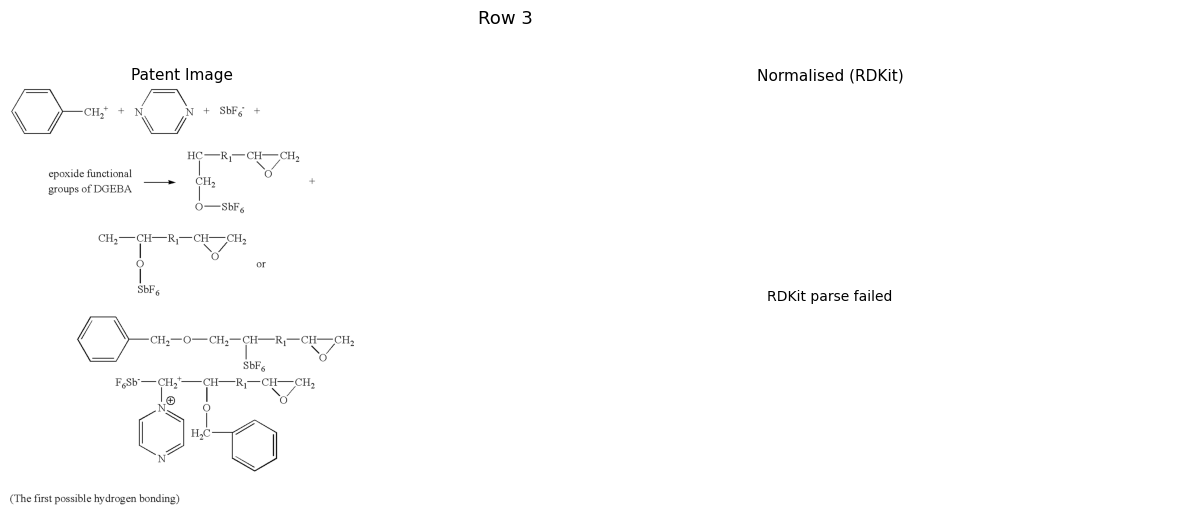

  Before: C1=CN=CC=N1.CC([1*]C1CO1)O[Sb](F)(F)(F)(F)(F)F.F[SbH-](F)(F)(F)(F)(F)[C+](C([1*]C1CO1)OCC1=CC=CC=C1)[N+]1=CC=NC=C1.F[Sb](F)(F)(F)(F)(F)C([1*]C1CO1)COCC1=CC=CC=C1.F[Sb](F)(F)(F)(F)(F)OCC[1*]C1CO1.F[Sb](F)(F)(F)F.[CH+2]C1=CC=CC=C1.[F-]
  After:  C1=CN=CC=N1.CC([R1]C1CO1)O[Sb](F)(F)(F)(F)(F)F.F[SbH-](F)(F)(F)(F)(F)[C+](C([R1]C1CO1)OCC1=CC=CC=C1)[N+]1=CC=NC=C1.F[Sb](F)(F)(F)(F)(F)C([R1]C1CO1)COCC1=CC=CC=C1.F[Sb](F)(F)(F)(F)(F)OCC[R1]C1CO1.F[Sb](F)(F)(F)F.[CH+2]C1=CC=CC=C1.[F-]
  Status: CHANGED



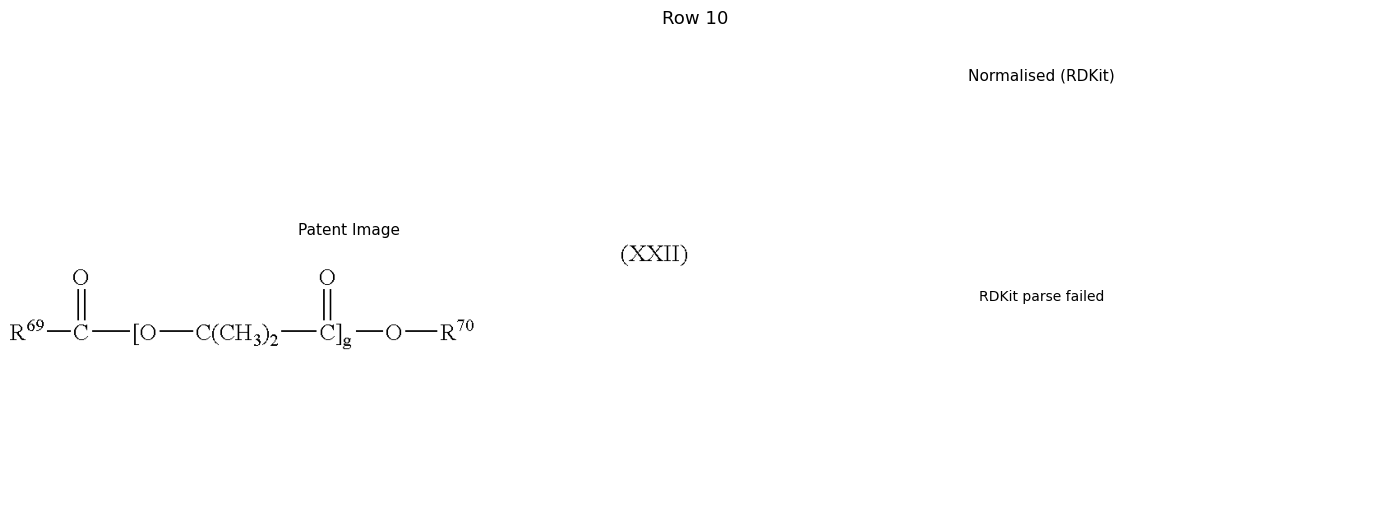

  Before: [69*]C(=O)[[O]C(C)C[C]g](=O)O[70*]
  After:  [R69]C(=O)[[O]C(C)C[C]g](=O)O[R70]
  Status: CHANGED



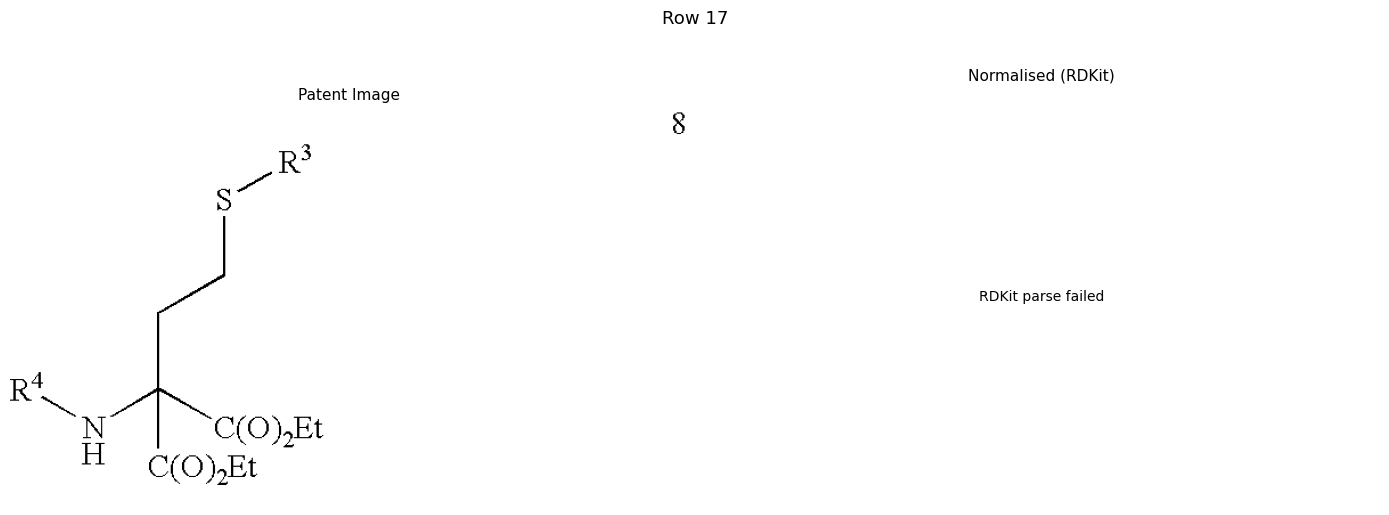

  Before: [3*]SCCC(N[4*])(C(=O)OCC)C(=O)OCC
  After:  [R3]SCCC(N[R4])(C(=O)OCC)C(=O)OCC
  Status: CHANGED



In [45]:
# Show a few representative changed examples across different wildcard types
print('=== Numbered [N*] → [RN] examples ===')
numbered_examples = df_changed[
    df_changed['smiles_before'].str.contains(r'\[\d+\*\]', regex=True, na=False)
    & ~df_changed['smiles_before'].apply(lambda s: _count_bare_stars(s) > 0 if isinstance(s, str) else False)
]
for idx in numbered_examples.index[:3]:
    show_comparison(idx)

=== Bare * → [R] (fallback) examples ===


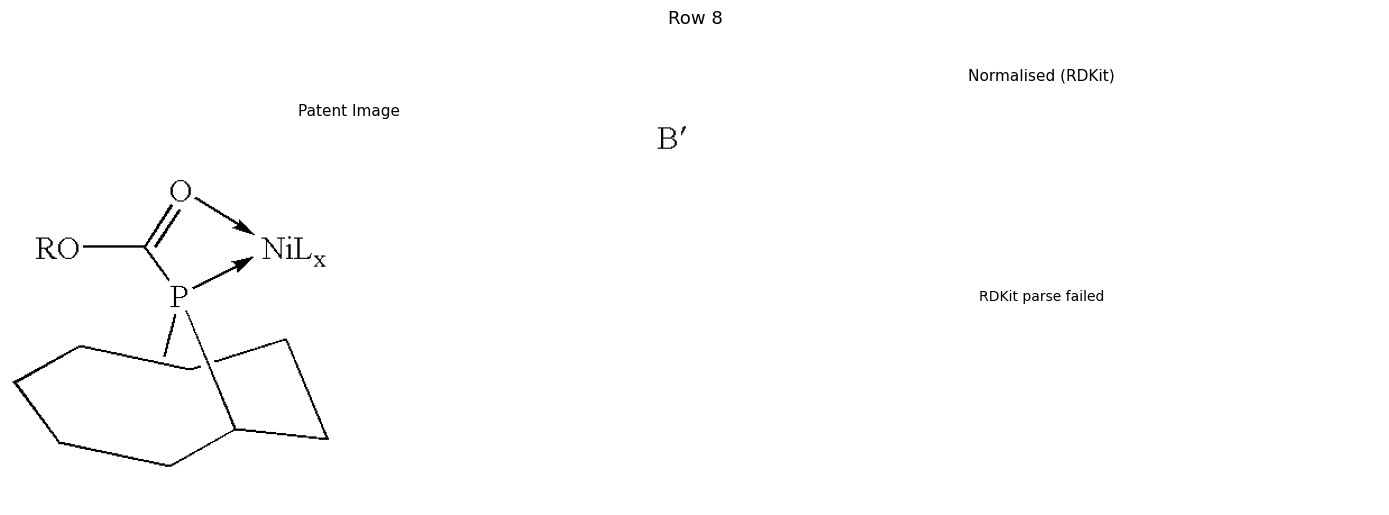

  Before: *OC1=[O+][NiLx][P+]1(C)C1CCCCCCC1
  After:  [R]OC1=[O+][NiLx][P+]1(C)C1CCCCCCC1
  Status: CHANGED



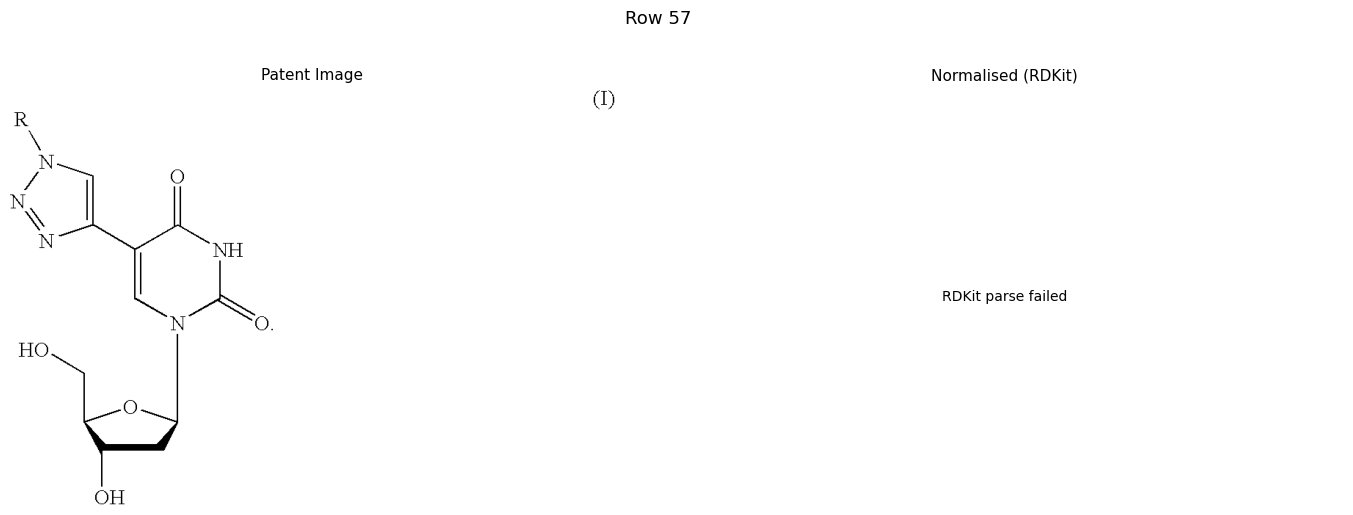

  Before: *N1C=C(C2=CN([C@H]3CC(O)[C@@H](CO)O3)C(=[O.])NC2=O)N=N1
  After:  [R]N1C=C(C2=CN([C@H]3CC(O)[C@@H](CO)O3)C(=[O.])NC2=O)N=N1
  Status: CHANGED



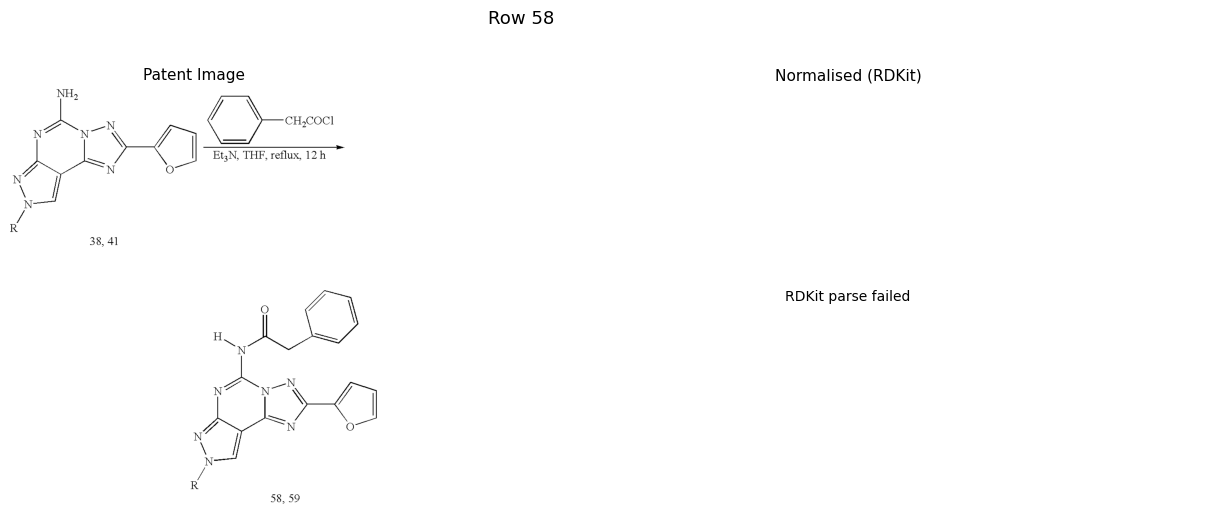

  Before: *N1C=C2C(=N1)N=C(N([H])C(=O)CC1=CC=CC=C1)N1N=C(C3=CC=CO3)N=C21.*N1C=C2C(=N1)N=C(N)N1N=C(C3=CC=CO3)N=C21.O=C(Cl)CC1=CC=CC=C1
  After:  [R]N1C=C2C(=N1)N=C(N([H])C(=O)CC1=CC=CC=C1)N1N=C(C3=CC=CO3)N=C21.[R]N1C=C2C(=N1)N=C(N)N1N=C(C3=CC=CO3)N=C21.O=C(Cl)CC1=CC=CC=C1
  Status: CHANGED



In [46]:
print('=== Bare * → [R] (fallback) examples ===')
bare_fallback = df_changed[
    df_changed['smiles_before'].apply(lambda s: _count_bare_stars(s) > 0 if isinstance(s, str) else False)
    & df_changed['smiles_after'].str.contains(r'\[R\]', regex=True, na=False)
    & ~df_changed['smiles_after'].str.contains(r'\[R\d', regex=True, na=False)
]
for idx in bare_fallback.index[:3]:
    show_comparison(idx)

=== Bare * → [X]/[A]/[M]/other label (MOL-derived) examples ===


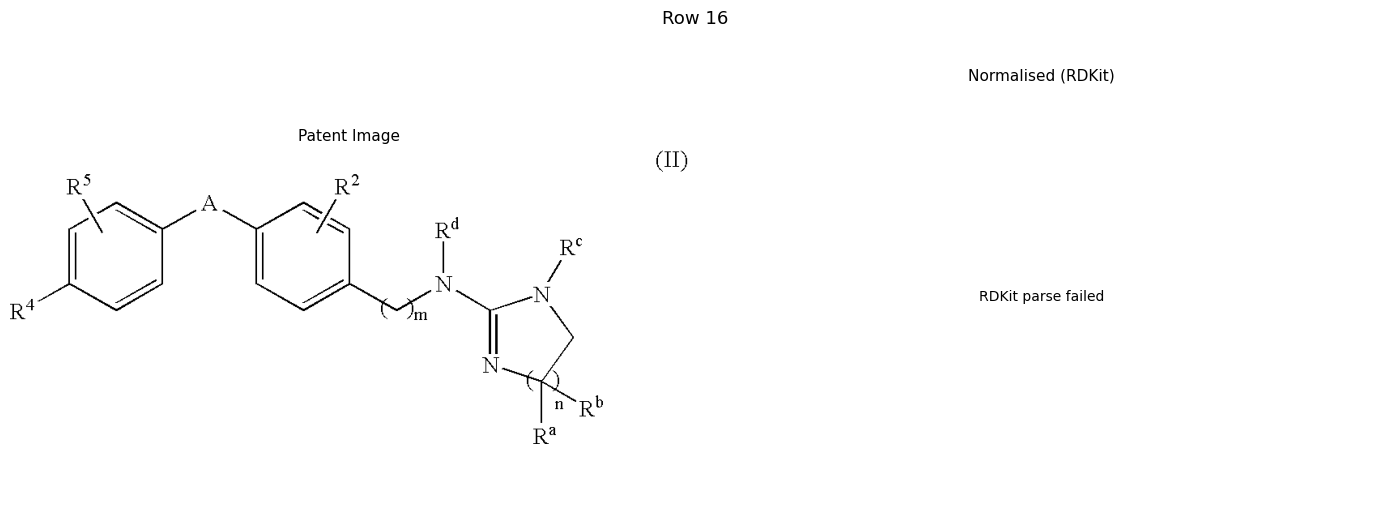

  Before: [2*]C.[4*]C1=CC=C(*C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C
  After:  [R2]C.[R4]C1=CC=C([A]C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C
  Status: CHANGED



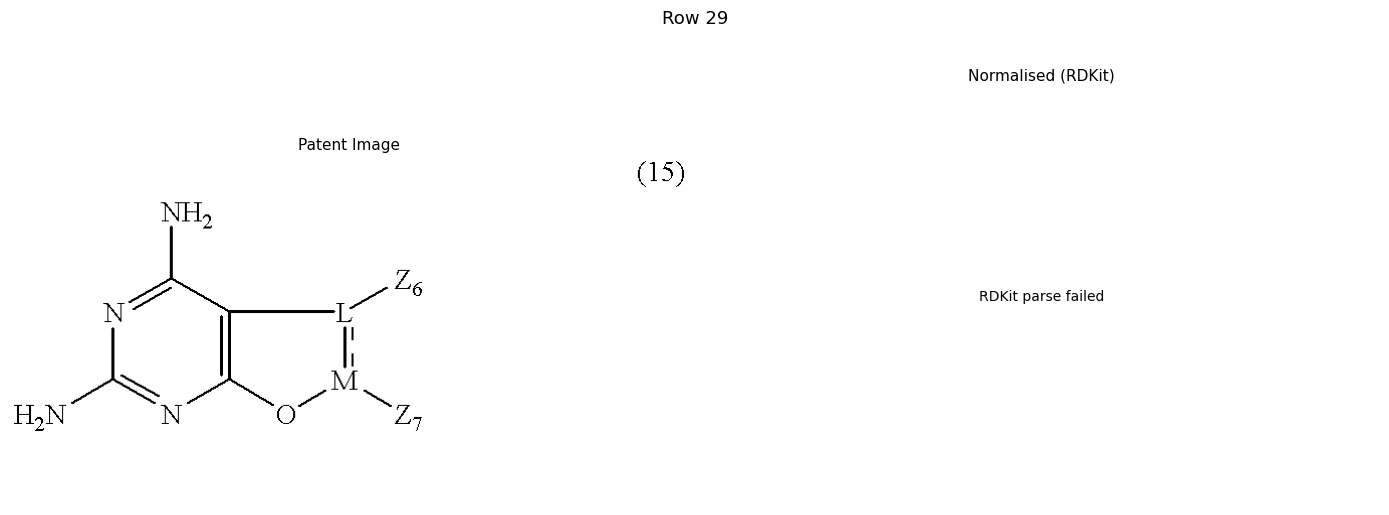

  Before: [Z7]*1OC2=C(*~1[Z6])C(N)=NC(N)=N2
  After:  [Z7][M]1OC2=C([L]~1[Z6])C(N)=NC(N)=N2
  Status: CHANGED



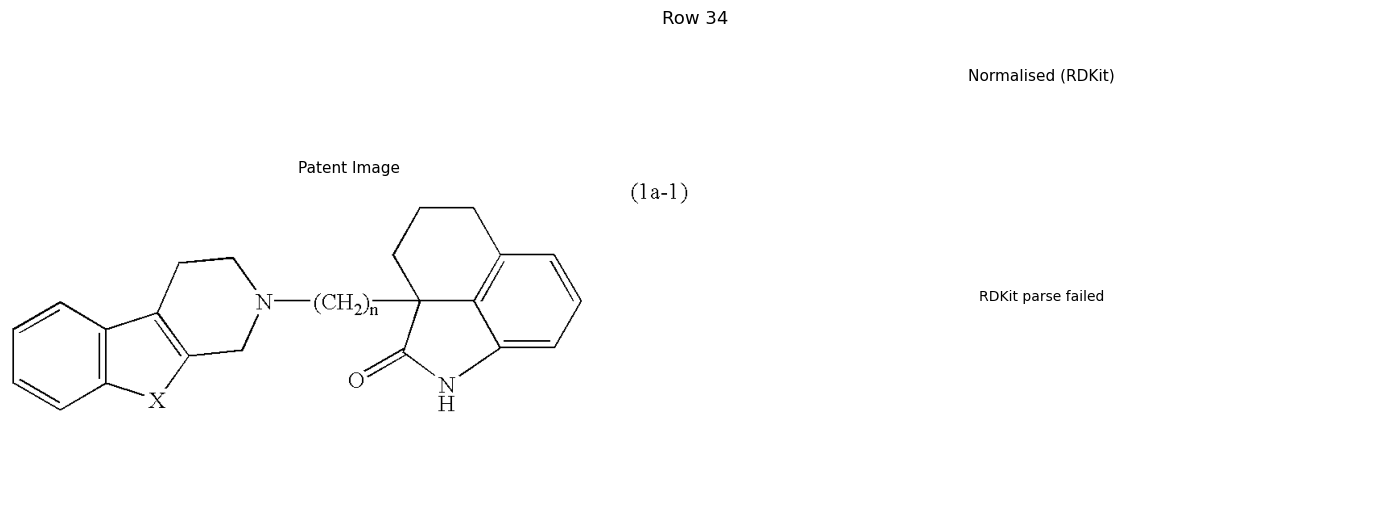

  Before: O=C1NC2=CC=CC3=C2C1([(CH2)n]N1CCC2=C(*C4=C2C=CC=C4)C1)CCC3
  After:  O=C1NC2=CC=CC3=C2C1([(CH2)n]N1CCC2=C([X]C4=C2C=CC=C4)C1)CCC3
  Status: CHANGED



In [47]:
print('=== Bare * → [X]/[A]/[M]/other label (MOL-derived) examples ===')
mol_derived = df_changed[
    df_changed['smiles_before'].apply(lambda s: _count_bare_stars(s) > 0 if isinstance(s, str) else False)
    & ~df_changed['smiles_after'].str.contains(r'(?<!\w)\[R\](?!\d)', regex=True, na=False)
]
for idx in mol_derived.index[:3]:
    show_comparison(idx)

=== Mixed: both [N*] and bare * ===
(45004 rows with both types)


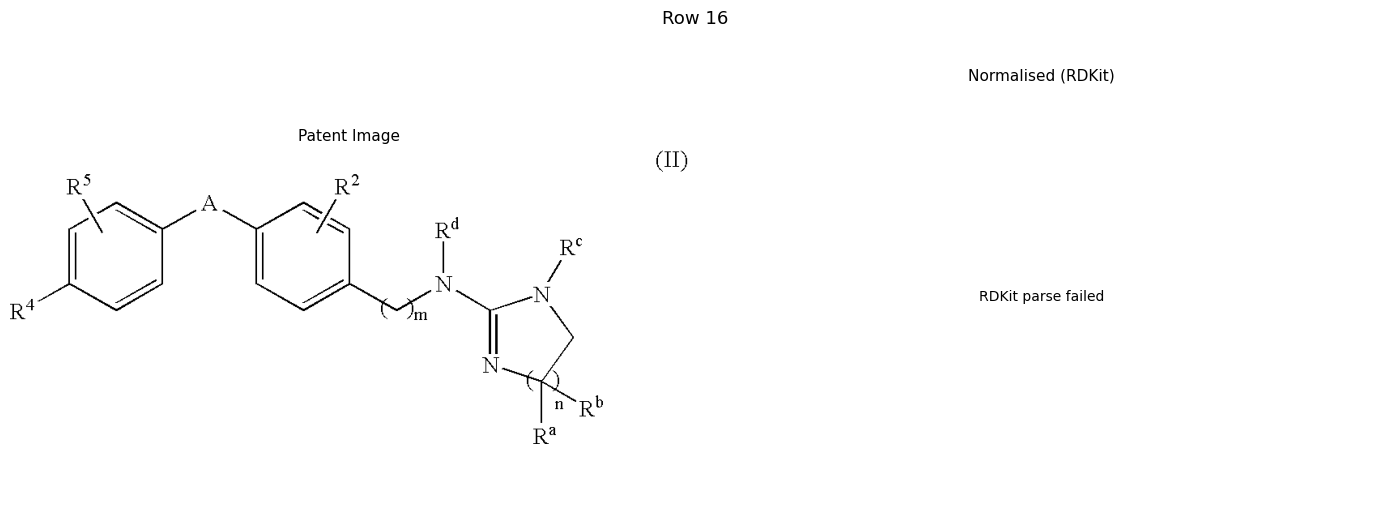

  Before: [2*]C.[4*]C1=CC=C(*C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C
  After:  [R2]C.[R4]C1=CC=C([A]C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C
  Status: CHANGED



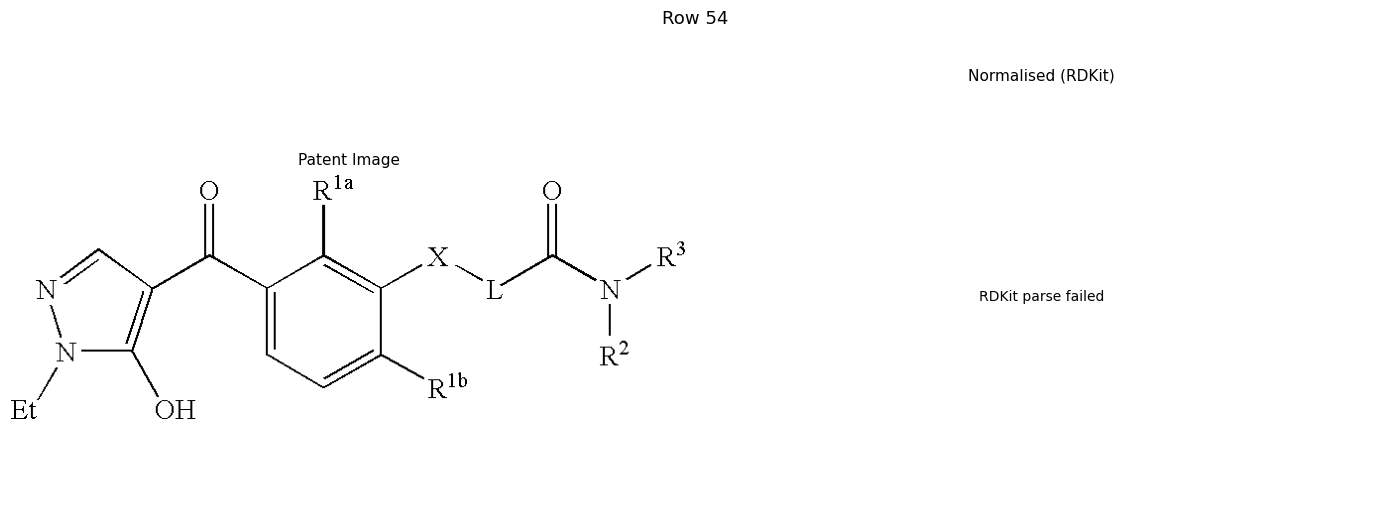

  Before: *C1=CC=C(C(=O)C2=C(O)N(CC)N=C2)C(*)=C1[X]*C(=O)N([2*])[3*]
  After:  [L]C1=CC=C(C(=O)C2=C(O)N(CC)N=C2)C([R1b])=C1[X][R1a]C(=O)N([R2])[R3]
  Status: CHANGED



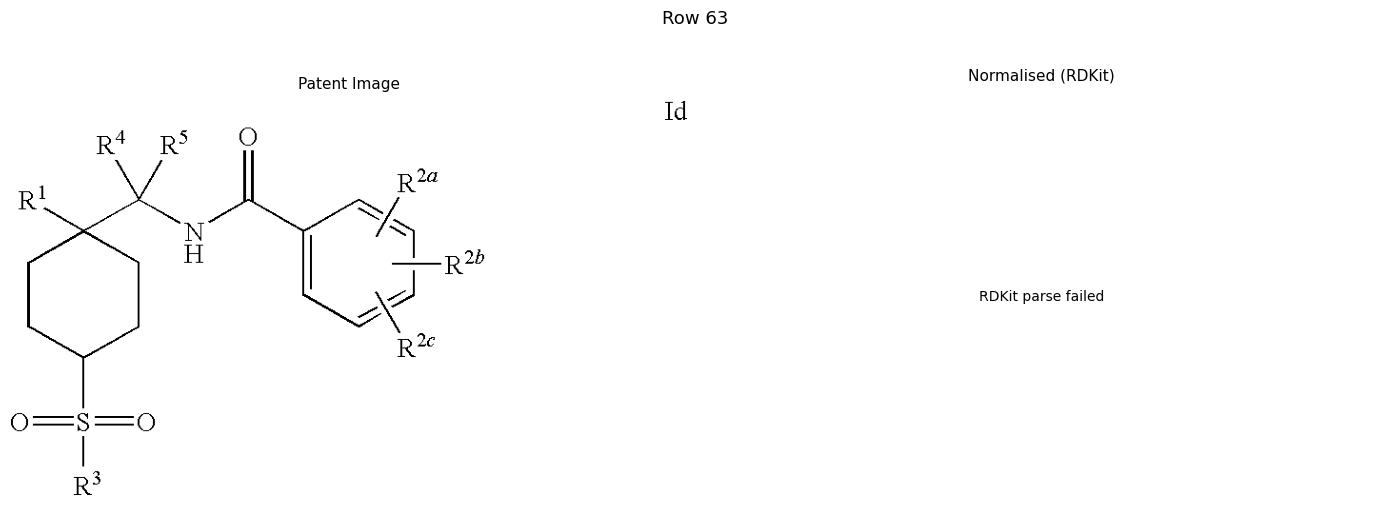

  Before: *C.*C.*C.[1*]C1(C([4*])([5*])NC(=O)C2=CC=CC=C2)CCC(S([3*])(=O)=O)CC1
  After:  [R2a]C.[R2c]C.[R2b]C.[R1]C1(C([R4])([R5])NC(=O)C2=CC=CC=C2)CCC(S([R3])(=O)=O)CC1
  Status: CHANGED



In [48]:
print('=== Mixed: both [N*] and bare * ===')
mixed = df_changed[
    df_changed['smiles_before'].str.contains(r'\[\d+\*\]', regex=True, na=False)
    & df_changed['smiles_before'].apply(lambda s: _count_bare_stars(s) > 0 if isinstance(s, str) else False)
]
print(f'({len(mixed)} rows with both types)')
for idx in mixed.index[:3]:
    show_comparison(idx)

## 7. Edge-Case Audit

Flag rows that might have problematic normalisation.

In [49]:
# 6a. Rows where MOL file doesn't exist (fallback to [R])
missing_mol = []
for idx, row in df_changed.head(2000).iterrows():
    mp = row['mol_path']
    if isinstance(mp, str):
        full = DATA_DIR / mp
        if not full.exists():
            missing_mol.append(idx)

print(f'Changed rows with missing MOL file (first 2000): {len(missing_mol)}')
if missing_mol:
    print('Examples:')
    for idx in missing_mol[:5]:
        row = df_changed.loc[idx]
        print(f'  Row {idx}: {row["mol_path"]}')
        print(f'    After: {row["smiles_after"][:100]}')

Changed rows with missing MOL file (first 2000): 0


In [50]:
# 6b. Rows where multiple different labels replace bare *
multi_label = []
for idx, row in df_changed.iterrows():
    before = row['smiles_before']
    after = row['smiles_after']
    if not isinstance(before, str) or not isinstance(after, str):
        continue
    if _count_bare_stars(before) < 2:
        continue
    # Find bracket labels in after that aren't in before
    orig_brackets = set(re.findall(r'\[([^\]]+)\]', before))
    new_brackets = [m for m in re.findall(r'\[([A-Z][A-Za-z0-9]*)\]', after)
                    if m not in orig_brackets]
    unique_new = set(new_brackets)
    if len(unique_new) > 1:
        multi_label.append((idx, unique_new))

print(f'Rows with multiple different new labels: {len(multi_label)}')
for idx, labels in multi_label[:10]:
    row = df_changed.loc[idx]
    print(f'  Row {idx}: labels={labels}')
    print(f'    Before: {row["smiles_before"][:100]}')
    print(f'    After:  {row["smiles_after"][:100]}')

Rows with multiple different new labels: 29842
  Row 29: labels={'M', 'L'}
    Before: [Z7]*1OC2=C(*~1[Z6])C(N)=NC(N)=N2
    After:  [Z7][M]1OC2=C([L]~1[Z6])C(N)=NC(N)=N2
  Row 45: labels={'R3T', 'R4T'}
    Before: *c1ccc(C#Cc2ccc(*)c(F)c2F)cc1.*c1ccc(C#Cc2ccc(C3CCC(*)CC3)cc2)c(F)c1F.[HH]
    After:  [R3T]c1ccc(C#Cc2ccc([R4T])c(F)c2F)cc1.[R4T]c1ccc(C#Cc2ccc(C3CCC([R3T])CC3)cc2)c(F)c1F.[HH]
  Row 54: labels={'R3', 'R1b', 'L', 'R1a', 'R2'}
    Before: *C1=CC=C(C(=O)C2=C(O)N(CC)N=C2)C(*)=C1[X]*C(=O)N([2*])[3*]
    After:  [L]C1=CC=C(C(=O)C2=C(O)N(CC)N=C2)C([R1b])=C1[X][R1a]C(=O)N([R2])[R3]
  Row 63: labels={'R2b', 'R2a', 'R1', 'R3', 'R5', 'R4', 'R2c'}
    Before: *C.*C.*C.[1*]C1(C([4*])([5*])NC(=O)C2=CC=CC=C2)CCC(S([3*])(=O)=O)CC1
    After:  [R2a]C.[R2c]C.[R2b]C.[R1]C1(C([R4])([R5])NC(=O)C2=CC=CC=C2)CCC(S([R3])(=O)=O)CC1
  Row 70: labels={'A', 'R1a'}
    Before: *C1=C([Z]*B)N(C2=CC3=C(C=CN=C3[0])C2)N=N1
    After:  [R1a]C1=C([Z][A]B)N(C2=CC3=C(C=CN=C3[0])C2)N=N1
  Row 77: labels={'X', 'Q

Long changed SMILES (>500 chars): 9


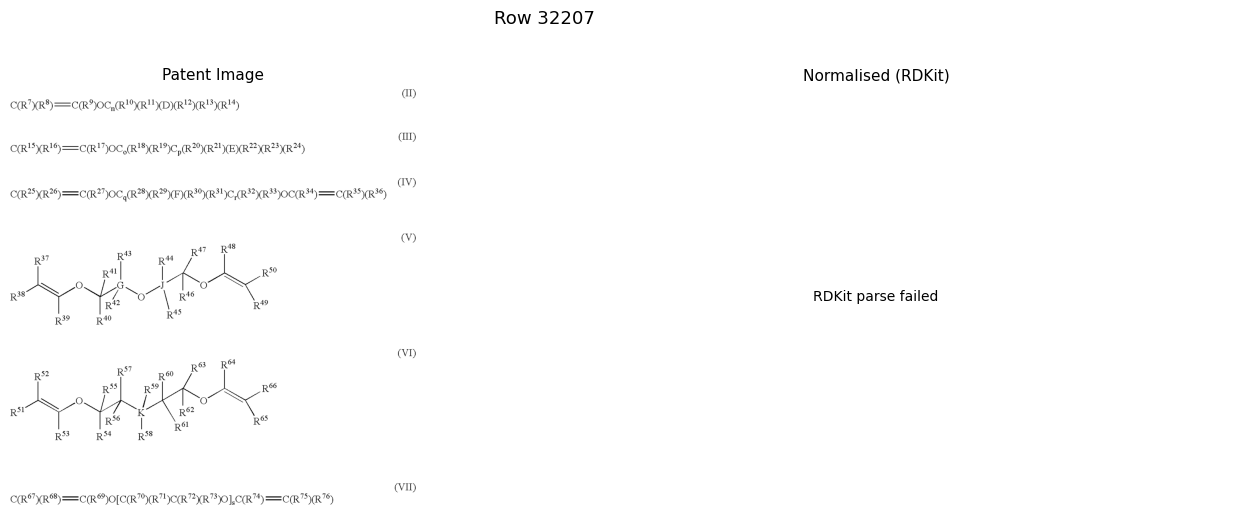

  Before: [C(R7)(R8)]=[C(R9)OCn(R10)(R11)(D)(R12)(R13)(R14)].[C(R15)(R16)]=[C(R17)OCo(R18)(R19)Cp(R20)(R21)(E)(R22)(R23)(R24)].[C(R25)(R26)]=[C(R27)OCq(R28)(R29)(F)(R30)(R31)Cr(R32)(R33)OC(R34)]=[C(R35)(R36)].[C(R67)(R68)]=[C(R69)O[C(R70)(R71)C(R72)(R73)O]sC(R74)]=[C(R75)(R76)].[37*]/C([38*])=C(/[39*])OC([40*])([41*])[G]([42*])([43*])O[J]([44*])([45*])C([46*])([47*])O/C([48*])=C(\[49*])[50*].[51*]/C([52*])=C(\[53*])OC([54*])([55*])C([56*])([57*])[K]([58*])([59*])C([60*])([61*])C([62*])([63*])O/C([64*])=C(\[65*])[66*]
  After:  [C(R7)(R8)]=[C(R9)OCn(R10)(R11)(D)(R12)(R13)(R14)].[C(R15)(R16)]=[C(R17)OCo(R18)(R19)Cp(R20)(R21)(E)(R22)(R23)(R24)].[C(R25)(R26)]=[C(R27)OCq(R28)(R29)(F)(R30)(R31)Cr(R32)(R33)OC(R34)]=[C(R35)(R36)].[C(R67)(R68)]=[C(R69)O[C(R70)(R71)C(R72)(R73)O]sC(R74)]=[C(R75)(R76)].[R37]/C([R38])=C(/[R39])OC([R40])([R41])[G]([R42])([R43])O[J]([R44])([R45])C([R46])([R47])O/C([R48])=C(\[R49])[R50].[R51]/C([R52])=C(\[R53])OC([R54])([R55])C([R56])([R57])[K]([R58])([R59])C([R60])([

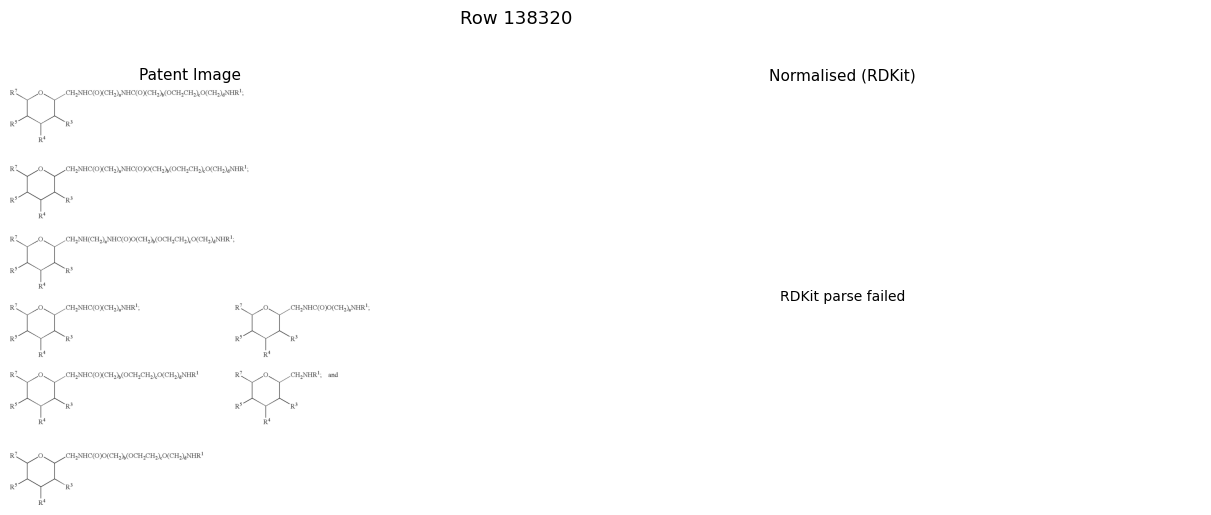

  Before: [and].[3*]C1C([CH2NHC(O)(CH2)aNHC(O)(CH2)b(OCH2CH2)cO(CH2)dNHR1;])OC([7*])C([5*])C1[4*].[3*]C1C([CH2NHC(O)(CH2)aNHC(O)O(CH2)b(OCH2CH2)cO(CH2)dNHR1;])OC([7*])C([5*])C1[4*].[3*]C1C([CH2NH(CH2)aNHC(O)O(CH2)b(OCH2CH2)cO(CH2)dNHR1;])OC([7*])C([5*])C1[4*].[3*]C1C([CH2NHC(O)(CH2)aNHR1;])OC([7*])C([5*])C1[4*].[3*]C1C([CH2NHC(O)O(CH2)aNHR1;])OC([7*])C([5*])C1[4*].[3*]C1C([CH2NHC(O)(CH2)b(OCH2CH2)cO(CH2)dNHR1])OC([7*])C([5*])C1[4*].[3*]C1C([CH2NHC(O)O(CH2)b(OCH2CH2)cO(CH2)dNHR1])OC([7*])C([5*])C1[4*].[3*]C1C([CH2NHR1;])OC([7*])C([5*])C1[4*]
  After:  [and].[R3]C1C([CH2NHC(O)(CH2)aNHC(O)(CH2)b(OCH2CH2)cO(CH2)dNHR1;])OC([R7])C([R5])C1[R4].[R3]C1C([CH2NHC(O)(CH2)aNHC(O)O(CH2)b(OCH2CH2)cO(CH2)dNHR1;])OC([R7])C([R5])C1[R4].[R3]C1C([CH2NH(CH2)aNHC(O)O(CH2)b(OCH2CH2)cO(CH2)dNHR1;])OC([R7])C([R5])C1[R4].[R3]C1C([CH2NHC(O)(CH2)aNHR1;])OC([R7])C([R5])C1[R4].[R3]C1C([CH2NHC(O)O(CH2)aNHR1;])OC([R7])C([R5])C1[R4].[R3]C1C([CH2NHC(O)(CH2)b(OCH2CH2)cO(CH2)dNHR1])OC([R7])C([R5])C1[R4].[R3]C1C([CH2NHC(O

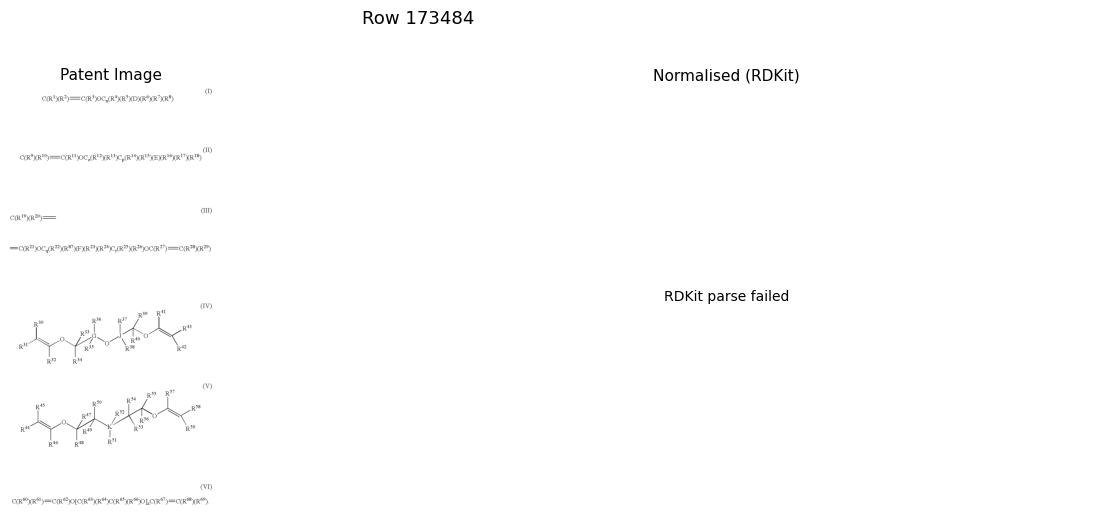

  Before: [C(R1)(R2)]=[C(R3)OCn(R4)(R5)(D)(R6)(R7)(R8)].[C(R9)(R10)]=[C(R11)OCo(R12)(R13)Cp(R14)(R15)(E)(R16)(R17)(R18)].[C(R19)(R20)]=C.[C(R60)(R61)]=[C(R62)O[C(R63)(R64)C(R65)(R66)O]zC(R67)]=[C(R68)(R69).].[C(R28)(R29)]=[C(R21)OCq(R22)(R87)(F)(R23)(R24)Cr(R25)(R26)OC(R27)]=C.[30*]/C([31*])=C(/[32*])OC([33*])([34*])[G]([35*])([36*])O[J]([37*])([38*])C([39*])([40*])O/C([41*])=C(\[42*])[43*].[44*]/C([45*])=C(\[46*])OC([47*])([48*])C([49*])([50*])C.[51*][K]([52*])C([53*])([54*])C([55*])([56*])O/C([57*])=C(/[58*])[59*]
  After:  [C(R1)(R2)]=[C(R3)OCn(R4)(R5)(D)(R6)(R7)(R8)].[C(R9)(R10)]=[C(R11)OCo(R12)(R13)Cp(R14)(R15)(E)(R16)(R17)(R18)].[C(R19)(R20)]=C.[C(R60)(R61)]=[C(R62)O[C(R63)(R64)C(R65)(R66)O]zC(R67)]=[C(R68)(R69).].[C(R28)(R29)]=[C(R21)OCq(R22)(R87)(F)(R23)(R24)Cr(R25)(R26)OC(R27)]=C.[R30]/C([R31])=C(/[R32])OC([R33])([R34])[G]([R35])([R36])O[J]([R37])([R38])C([R39])([R40])O/C([R41])=C(\[R42])[R43].[R44]/C([R45])=C(\[R46])OC([R47])([R48])C([R49])([R50])C.[R51][K]([R52])C([R53])([R5

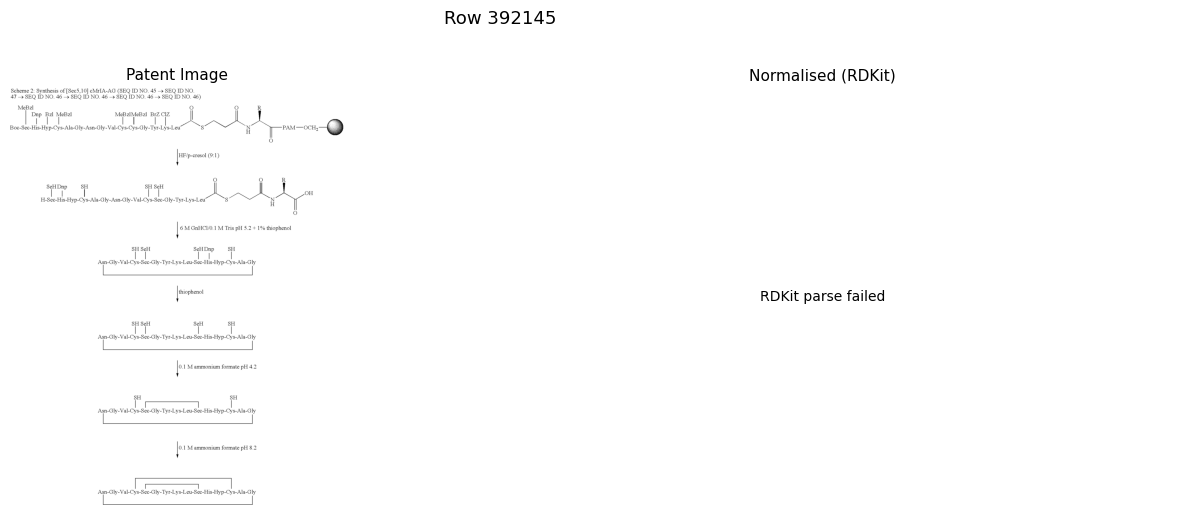

  Before: *[C@H](NC(=O)CCSC(=O)[Boc-Sec-His-Hyp-Cys-Ala-Gly-Asn-Gly-Val-Cys-Cys-Gly-Tyr-Lys-Leu]([Dnp])([MeBzl])([ClZ])([BrZ])([MeBzl])([MeBzl])([MeBzl])CC1=CC=CC=C1)C(=O)[PAM]OCC.*[C@H](NC(=O)CCSC(=O)[H-Sec-His-Hyp-Cys-Ala-Gly-Asn-Gly-Val-Cys-Sec-Gly-Tyr-Lys-Leu]([Dnp])(S)(S)([SeH])[SeH])C(=O)O.C1C[Asn-Gly-Val-Cys-Sec-Gly-Tyr-Lys-Leu-Sec-His-Hyp-Cys-Ala-Gly]123(CC2)CC3.[Dnp][Asn-Gly-Val-Cys-Sec-Gly-Tyr-Lys-Leu-Sec-His-Hyp-Cys-Ala-Gly]1(S)(S)([SeH])([SeH])CC1.S[Asn-Gly-Val-Cys-Sec-Gly-Tyr-Lys-Leu-Sec-His-Hyp-Cys-Ala-Gly]1(S)([SeH])([SeH])CC1.S[Asn-Gly-Val-Cys-Sec-Gly-Tyr-Lys-Leu-Sec-His-Hyp-Cys-Ala-Gly]12(S)(CC1)CC2
  After:  [R][C@H](NC(=O)CCSC(=O)[Boc-Sec-His-Hyp-Cys-Ala-Gly-Asn-Gly-Val-Cys-Cys-Gly-Tyr-Lys-Leu]([Dnp])([MeBzl])([ClZ])([BrZ])([MeBzl])([MeBzl])([MeBzl])CC1=CC=CC=C1)C(=O)[PAM]OCC.[R][C@H](NC(=O)CCSC(=O)[H-Sec-His-Hyp-Cys-Ala-Gly-Asn-Gly-Val-Cys-Sec-Gly-Tyr-Lys-Leu]([Dnp])(S)(S)([SeH])[SeH])C(=O)O.C1C[Asn-Gly-Val-Cys-Sec-Gly-Tyr-Lys-Leu-Sec-His-Hyp-Cys-Ala-Gly]123(CC2)CC3

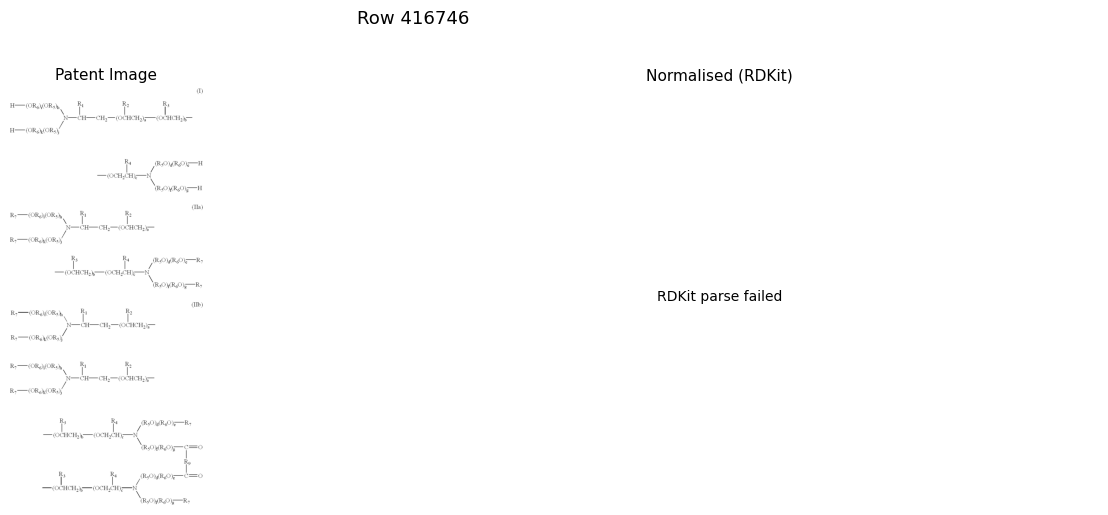

  Before: [1*]C(C[(OCHCH2)a]([2*])[(OCHCH2)b]([3*])C)N([(OR6)i(OR5)h][H])[(OR6)k(OR5)j][H].[1*]C(C[(OCHCH2)a]([2*])C)N([(OR6)i(OR5)h][7*])[(OR6)k(OR5)j][7*].[1*]C(C[(OCHCH2)a]([2*])C)N([(OR6)i(OR5)h][7*])[(OR6)k(OR5)j][7*].[1*]C(C[(OCHCH2)a]([2*])C)N([(OR6)i(OR5)h][7*])[(OR6)k(OR5)j][7*].[3*][(OCHCH2)b](C)[(OCH2CH)c]([4*])N([(R5O)d(R6O)e][7*])[(R5O)f(R6O)g]C(=O)[9*]C(=O)[(R5O)d(R6O)e]N([(R5O)f(R6O)g][7*])[(OCH2CH)c]([4*])[(OCHCH2)b]([3*])C.[3*][(OCHCH2)b](C)[(OCH2CH)c]([4*])N([(R5O)d(R6O)e][7*])[(R5O)f(R6O)g][7*].[4*][(OCH2CH)c](C)N([(R5O)d(R6O)e][H])[(R5O)f(R6O)g][H]
  After:  [R1]C(C[(OCHCH2)a]([R2])[(OCHCH2)b]([R3])C)N([(OR6)i(OR5)h][H])[(OR6)k(OR5)j][H].[R1]C(C[(OCHCH2)a]([R2])C)N([(OR6)i(OR5)h][R7])[(OR6)k(OR5)j][R7].[R1]C(C[(OCHCH2)a]([R2])C)N([(OR6)i(OR5)h][R7])[(OR6)k(OR5)j][R7].[R1]C(C[(OCHCH2)a]([R2])C)N([(OR6)i(OR5)h][R7])[(OR6)k(OR5)j][R7].[R3][(OCHCH2)b](C)[(OCH2CH)c]([R4])N([(R5O)d(R6O)e][R7])[(R5O)f(R6O)g]C(=O)[R9]C(=O)[(R5O)d(R6O)e]N([(R5O)f(R6O)g][R7])[(OCH2CH)c]([R4])

In [51]:
# 6c. Very long SMILES that changed — worth a manual look
long_changed = df_changed[df_changed['smiles_before'].str.len() > 500].head(5)
print(f'Long changed SMILES (>500 chars): {len(df_changed[df_changed["smiles_before"].str.len() > 500])}')
for idx in long_changed.index:
    show_comparison(idx)

In [52]:
# 6d. Rows where RDKit cannot parse the normalised SMILES
if HAS_RDKIT:
    parse_failures = []
    for idx, row in df_changed.iterrows():
        smi = row['smiles_after']
        if isinstance(smi, str):
            mol = Chem.MolFromSmiles(smi, sanitize=False)
            if mol is None:
                parse_failures.append(idx)
    
    print(f'Normalised SMILES that RDKit cannot parse: {len(parse_failures)} / {len(df_changed)}')
    if parse_failures:
        print('Examples:')
        for idx in parse_failures[:5]:
            row = df_changed.loc[idx]
            print(f'  Row {idx}: {row["smiles_after"][:100]}')
else:
    print('Skipped (RDKit not available).')

Normalised SMILES that RDKit cannot parse: 220535 / 220535
Examples:
  Row 3: C1=CN=CC=N1.CC([R1]C1CO1)O[Sb](F)(F)(F)(F)(F)F.F[SbH-](F)(F)(F)(F)(F)[C+](C([R1]C1CO1)OCC1=CC=CC=C1)
  Row 8: [R]OC1=[O+][NiLx][P+]1(C)C1CCCCCCC1
  Row 10: [R69]C(=O)[[O]C(C)C[C]g](=O)O[R70]
  Row 16: [R2]C.[R4]C1=CC=C([A]C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C
  Row 17: [R3]SCCC(N[R4])(C(=O)OCC)C(=O)OCC


## 8. Interactive Spot-Check

Use this cell to manually inspect any specific row by index.

=== Row 16 ===
File:  uspto_mol/2006/I20060718/US07078401-20060718/US07078401-20060718-C00007.TIF
MOL:   uspto_mol/2006/I20060718/US07078401-20060718/US07078401-20060718-C00007.MOL
Before: [2*]C.[4*]C1=CC=C(*C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C
After:  [R2]C.[R4]C1=CC=C([A]C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C

MOL element symbols (29 atoms): ['C', 'R2', 'C', 'C', 'C', 'C', 'R4', 'A', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'N', 'C', 'C', 'N', 'C', 'C', 'N', 'C', 'Ra', 'Rb', 'C', 'C', 'C', 'R5']
Non-standard atoms: [(1, 'R2'), (6, 'R4'), (7, 'A'), (23, 'Ra'), (24, 'Rb'), (28, 'R5')]
Ordered bare labels: ['A']
Re-normalised: [R2]C.[R4]C1=CC=C([A]C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C
Match: True



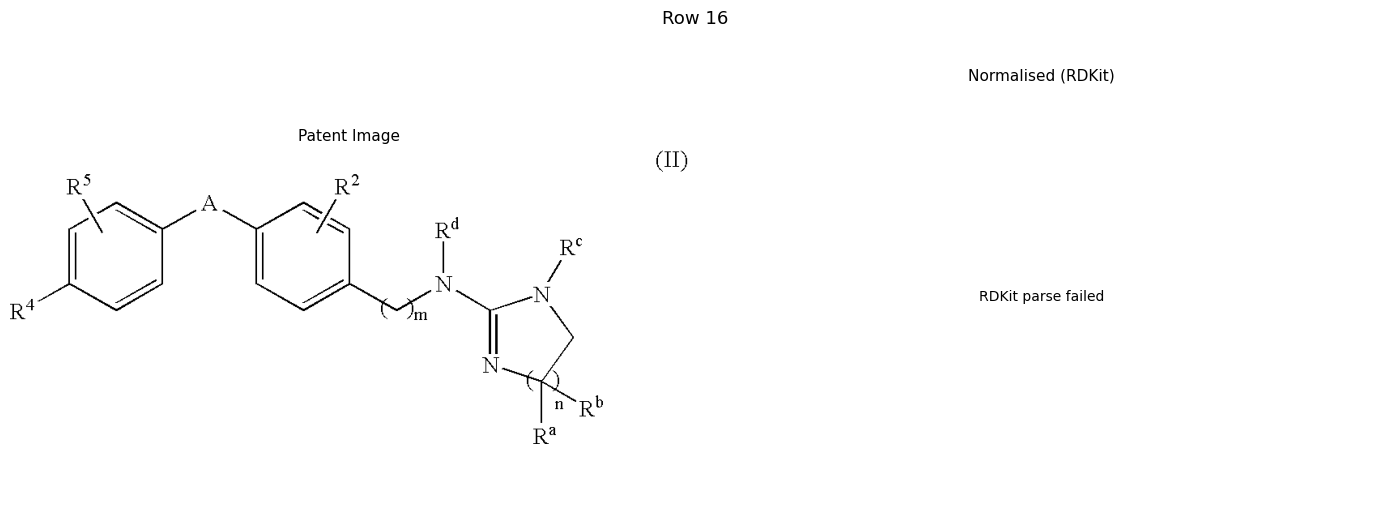

  Before: [2*]C.[4*]C1=CC=C(*C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C
  After:  [R2]C.[R4]C1=CC=C([A]C2=CC=C(CN([Rd])C3=NC([Rb])([RaH])CN3[Rc])C=C2)C=C1.[0]C
  Status: CHANGED



In [53]:
# Change this index to inspect any row
ROW_INDEX = 16  # example with bare * and MOL-derived labels

row = df.iloc[ROW_INDEX]
mol_path = str(DATA_DIR / row['mol_path']) if isinstance(row['mol_path'], str) else None

print(f'=== Row {ROW_INDEX} ===')
print(f'File:  {row["file_path"]}')
print(f'MOL:   {row["mol_path"]}')
print(f'Before: {row["smiles_before"]}')
print(f'After:  {row["smiles_after"]}')
print()

if mol_path and os.path.isfile(mol_path):
    syms = parse_mol_element_symbols(mol_path)
    print(f'MOL element symbols ({len(syms)} atoms): {syms}')
    non_standard = [(i, s) for i, s in enumerate(syms) if s not in (
        'C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'H',
        'Si', 'B', 'Se', 'Te', 'As', 'Ge', 'Sn', 'Pb'
    )]
    if non_standard:
        print(f'Non-standard atoms: {non_standard}')
    
    ordered = _get_ordered_bare_labels(mol_path)
    print(f'Ordered bare labels: {ordered}')
    
    re_norm = normalise_rgroup(row['smiles_before'], mol_path)
    print(f'Re-normalised: {re_norm}')
    print(f'Match: {re_norm == row["smiles_after"]}')

print()
show_comparison(ROW_INDEX)

## 9. Aggregate Report

In [ ]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║          SMILES Normalisation Verification Report          ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Total rows:                  {len(df):>8d}                     ║')
print(f'║  Changed rows:                {len(df_changed):>8d}  ({100*len(df_changed)/len(df):>5.1f}%)        ║')
print(f'║                                                            ║')
print(f'║  — Annotation Filtering —                                  ║')
print(f'║  Rows with fragments removed: {n_filter_changed:>8d}                     ║')
print(f'║  Unique fragment types:        {len(removed_frags):>7d}                     ║')
n_suspect_fp = len(suspect_false_positives) if HAS_RDKIT else -1
if n_suspect_fp >= 0:
    print(f'║  Suspect false positives:     {n_suspect_fp:>8d}                     ║')
print(f'║  Idempotency mismatches:      {ann_repro_mismatches:>8d}                     ║')
print(f'║                                                            ║')
print(f'║  — R-Group Normalisation —                                 ║')
print(f'║  [N*]→[RN] leftover:          {len(leftover):>8d}                     ║')
print(f'║  Bare * leftover:             {len(still_bare):>8d}                     ║')
print(f'║  Non-wildcard unexplained:    {len(unexplained):>8d}                     ║')
print(f'║                                                            ║')
print(f'║  — Cross-Validation —                                      ║')
print(f'║  Sample size:                 {len(df_xval):>8d}                     ║')
print(f'║  Reproducible:                {df_xval["reproducible"].sum():>8d}                     ║')
print(f'║  Label mismatches:            {len(label_mismatch):>8d}                     ║')
if HAS_RDKIT:
    print(f'║  RDKit parse failures:        {len(parse_failures):>8d}                     ║')
print('╚══════════════════════════════════════════════════════════════╝')

all_ok = (
    len(leftover) == 0
    and len(still_bare) == 0
    and len(unexplained) == 0
    and df_xval['reproducible'].all()
    and len(label_mismatch) == 0
    and ann_repro_mismatches == 0
)
if all_ok:
    print('\n✓ All automated checks passed.')
else:
    print('\n⚠ Some checks flagged issues — review the sections above.')

╔══════════════════════════════════════════════════════════╗
║          R-Group Normalisation Verification Report      ║
╠══════════════════════════════════════════════════════════╣
║  Total rows:                680220                     ║
║  Changed rows:              220535  ( 32.4%)        ║
║                                                        ║
║  [N*]→[RN] leftover:             0                     ║
║  Bare * leftover:                0                     ║
║  Non-wildcard changed:           0                     ║
║                                                        ║
║  Cross-validation sample:      500                     ║
║  Reproducible:                 500                     ║
║  Label mismatches:               5                     ║
║  RDKit parse failures:      220535                     ║
╚══════════════════════════════════════════════════════════╝

⚠ Some checks flagged issues — review the sections above.
